In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#importing the dataset from local storage
df = pd.read_csv('C:/Users/Joni/Desktop/Datasets/Crime_Data_from_2020_to_2024.csv')

In [3]:
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,4/11/2021 0:00,11/7/2020 0:00,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 0:00,10/18/2020 0:00,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 0:00,10/30/2020 0:00,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 0:00,12/24/2020 0:00,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/3/2020 0:00,9/29/2020 0:00,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [4]:
#cheking the data type
df.dtypes

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA                int64
AREA NAME          object
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc        object
Mocodes            object
Vict Age            int64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object

In [5]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

In [6]:
df.dtypes

DR_NO                      int64
Date Rptd                 object
DATE OCC          datetime64[ns]
TIME OCC                   int64
AREA                       int64
AREA NAME                 object
Rpt Dist No                int64
Part 1-2                   int64
Crm Cd                     int64
Crm Cd Desc               object
Mocodes                   object
Vict Age                   int64
Vict Sex                  object
Vict Descent              object
Premis Cd                float64
Premis Desc               object
Weapon Used Cd           float64
Weapon Desc               object
Status                    object
Status Desc               object
Crm Cd 1                 float64
Crm Cd 2                 float64
Crm Cd 3                 float64
Crm Cd 4                 float64
LOCATION                  object
Cross Street              object
LAT                      float64
LON                      float64
dtype: object

In [7]:
df[['Date Rptd', 'DATE OCC']].head()

,Date Rptd,DATE OCC
0,4/11/2021 0:00,2020-11-07
1,10/21/2020 0:00,2020-10-18
2,12/10/2024 0:00,2020-10-30
3,12/24/2020 0:00,2020-12-24
4,10/3/2020 0:00,2020-09-29


In [8]:
totalCrime = df['DR_NO'].count()

In [9]:
totalCrime

1004894

In [10]:
df['DATE OCC'].min()

Timestamp('2020-01-01 00:00:00')

In [11]:
df['DATE OCC'].max()

Timestamp('2024-12-30 00:00:00')

In [12]:
!pip install pandas_datareader

In [13]:
import datetime
import pandas_datareader.data as web
from matplotlib import style

In [14]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [15]:
df['DATE OCC'].map(lambda x: x.strftime("%A")).head()

0    Saturday
1      Sunday
2      Friday
3    Thursday
4     Tuesday
Name: DATE OCC, dtype: object

In [16]:
df['Occ_weekday'] = df['DATE OCC'].map(lambda x: x.strftime("%A"))

In [17]:
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Occ_weekday
0,211507896,4/11/2021 0:00,2020-11-07,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092,Saturday
1,201516622,10/21/2020 0:00,2020-10-18,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,Invest Cont,230.0,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203,Sunday
2,240913563,12/10/2024 0:00,2020-10-30,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,Invest Cont,354.0,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509,Friday
3,210704711,12/24/2020 0:00,2020-12-24,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,Invest Cont,331.0,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747,Thursday
4,201418201,10/3/2020 0:00,2020-09-29,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,Invest Cont,420.0,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350,Tuesday


In [18]:
df['Occ_weekday'].value_counts()

Occ_weekday
Friday       153663
Saturday     147457
Wednesday    142688
Thursday     141792
Monday       141532
Sunday       139637
Tuesday      138125
Name: count, dtype: int64

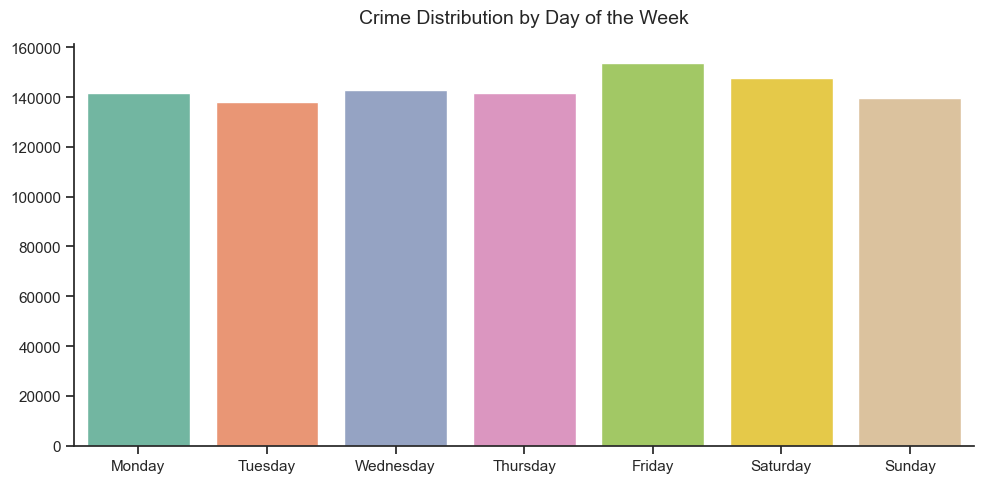

In [19]:
#Make sure the column is in corret format
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

# Creating column in name of weekday
df['Occ_weekday'] = df['DATE OCC'].dt.day_name()

# Defining order os the days
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_por_dia = df['Occ_weekday'].value_counts().reindex(dias_ordenados)

# Set the chart
plt.figure(figsize=(10, 5))
sns.set_theme(style="ticks")

# Create the chart bars
sns.barplot(x=crimes_por_dia.index, y=crimes_por_dia.values, palette='Set2')

# Title
plt.title('Crime Distribution by Day of the Week', fontsize=14, pad=15)

# Remove the name of axis X and Y
plt.xlabel('')  
plt.ylabel('')  

plt.xticks(ticks=range(7), labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

sns.despine()

# Ajust the layout
plt.tight_layout()
plt.show()

In [20]:
df[['Crm Cd', 'Crm Cd Desc']].value_counts().head(10)

Crm Cd  Crm Cd Desc                                            
510     VEHICLE - STOLEN                                           115184
624     BATTERY - SIMPLE ASSAULT                                    74821
330     BURGLARY FROM VEHICLE                                       63515
354     THEFT OF IDENTITY                                           62536
740     VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     61086
310     BURGLARY                                                    57871
440     THEFT PLAIN - PETTY ($950 & UNDER)                          53716
230     ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              53523
626     INTIMATE PARTNER - SIMPLE ASSAULT                           46712
420     THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             41311
Name: count, dtype: int64

In [21]:
Crime_agg = df.groupby(['Crm Cd', 'Crm Cd Desc', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'], dropna = False).size().reset_index(name='Total')

In [22]:
print(Crime_agg.sort_values(by='Total',ascending = False).head(3))

     Crm Cd               Crm Cd Desc  Crm Cd 2  Crm Cd 3  Crm Cd 4   Total
808     510          VEHICLE - STOLEN       NaN       NaN       NaN  114913
872     624  BATTERY - SIMPLE ASSAULT       NaN       NaN       NaN   72867
496     330     BURGLARY FROM VEHICLE       NaN       NaN       NaN   61710


In [23]:
multiple_crime = df[['Crm Cd', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']].notnull().sum()

In [24]:
print(multiple_crime)

Crm Cd      1004894
Crm Cd 2      69154
Crm Cd 3       2314
Crm Cd 4         64
dtype: int64


In [25]:
df_crime = df.melt(id_vars=['Crm Cd', 'Crm Cd Desc', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'], var_name = 'crime_hierarchy', value_name ='Cod_Crime')

In [26]:
agg = df.groupby(['Crm Cd', 'Crm Cd Desc', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4']).size().reset_index(name='Total')

In [27]:
print(agg.sort_values(by='Total', ascending=False).head(3))

    Crm Cd                            Crm Cd Desc  Crm Cd 2  Crm Cd 3  \
32     761                        BRANDISH WEAPON     761.0     930.0   
27     624               BATTERY - SIMPLE ASSAULT     625.0     930.0   
23     236  INTIMATE PARTNER - AGGRAVATED ASSAULT     761.0     930.0   

    Crm Cd 4  Total  
32     998.0      9  
27     998.0      4  
23     998.0      3  


In [28]:
multiple_crime = agg[agg['Crm Cd 2'].notnull()]
print(multiple_crime.sort_values(by='Total', ascending=False).head(10))

    Crm Cd                            Crm Cd Desc  Crm Cd 2  Crm Cd 3  \
32     761                        BRANDISH WEAPON     761.0     930.0   
27     624               BATTERY - SIMPLE ASSAULT     625.0     930.0   
23     236  INTIMATE PARTNER - AGGRAVATED ASSAULT     761.0     930.0   
46     820                        ORAL COPULATION     820.0     910.0   
30     761                        BRANDISH WEAPON     626.0     761.0   
0      110                      CRIMINAL HOMICIDE     230.0     648.0   
36     761                        BRANDISH WEAPON     930.0     997.0   
28     624               BATTERY - SIMPLE ASSAULT     740.0     902.0   
29     753         DISCHARGE FIREARMS/SHOTS FIRED     946.0     998.0   
31     761                        BRANDISH WEAPON     761.0     888.0   

    Crm Cd 4  Total  
32     998.0      9  
27     998.0      4  
23     998.0      3  
46     998.0      2  
30     998.0      2  
0      998.0      1  
36     998.0      1  
28     998.0      1 

In [29]:
mapa_crime = df[['Crm Cd', 'Crm Cd Desc']].drop_duplicates().set_index('Crm Cd')['Crm Cd Desc'].to_dict()

In [30]:
print(mapa_crime.get(510))

VEHICLE - STOLEN


In [31]:
df_crime['Desc_crime'] = df_crime['Cod_Crime'].map(mapa_crime)

In [32]:
top5 = df_crime['Desc_crime'].value_counts().head(5)

In [33]:
print(top5)

Desc_crime
VEHICLE - STOLEN                                           117142
BATTERY - SIMPLE ASSAULT                                    75219
BURGLARY FROM VEHICLE                                       67145
THEFT OF IDENTITY                                           63344
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     62389
Name: count, dtype: int64


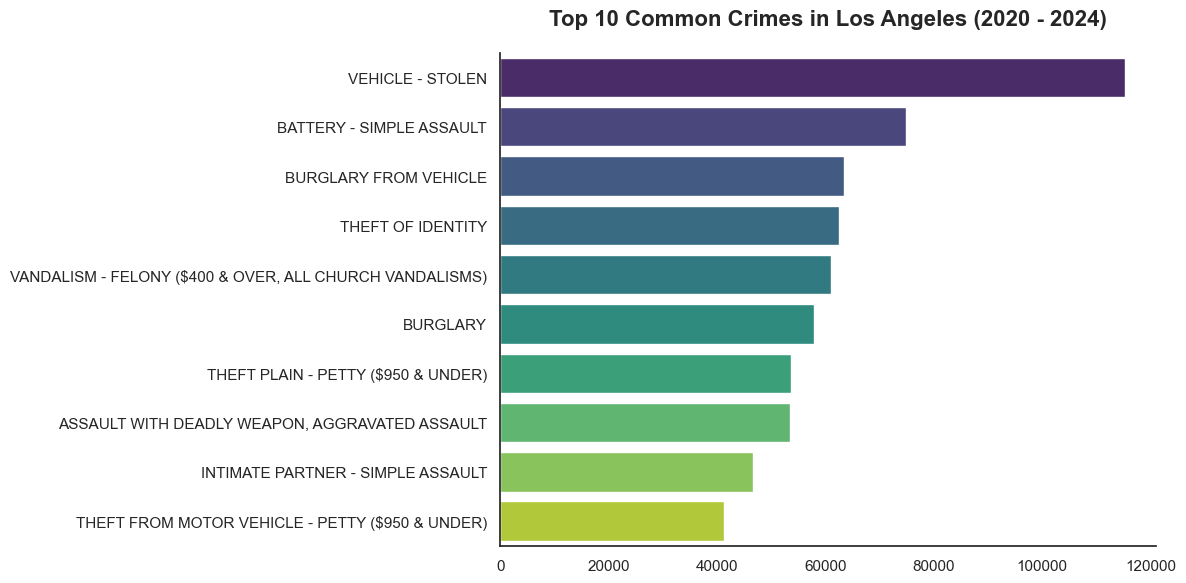

In [34]:
# Count the frequences of crimes Top 10
top_crimes = df['Crm Cd Desc'].value_counts().head(10).reset_index()
top_crimes.columns = ['Crime', 'Total']

# 2. Set the Style
sns.set_style("white") 
plt.figure(figsize=(12, 6))

# 3. Creating horizontals bars chart
# Define y='Crime' e x='Total' 
sns.barplot(
    data=top_crimes, 
    x='Total', 
    y='Crime', 
    palette='viridis'
)

#Title
plt.title('Top 10 Common Crimes in Los Angeles (2020 - 2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('') 
plt.ylabel('') 

# set the size os axis
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# 5. Remove the top and right borders
sns.despine()

plt.tight_layout()
plt.show()

In [35]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])

In [36]:
df['Year'] = df['DATE OCC'].dt.year

In [37]:
crimes_per_year = df.groupby('Year')['DR_NO'].count().reset_index()

In [38]:
crimes_per_year.columns = ['Year', 'Total_Crimes']

In [39]:
print(crimes_per_year)

   Year  Total_Crimes
0  2020        199847
1  2021        209876
2  2022        235259
3  2023        232345
4  2024        127567


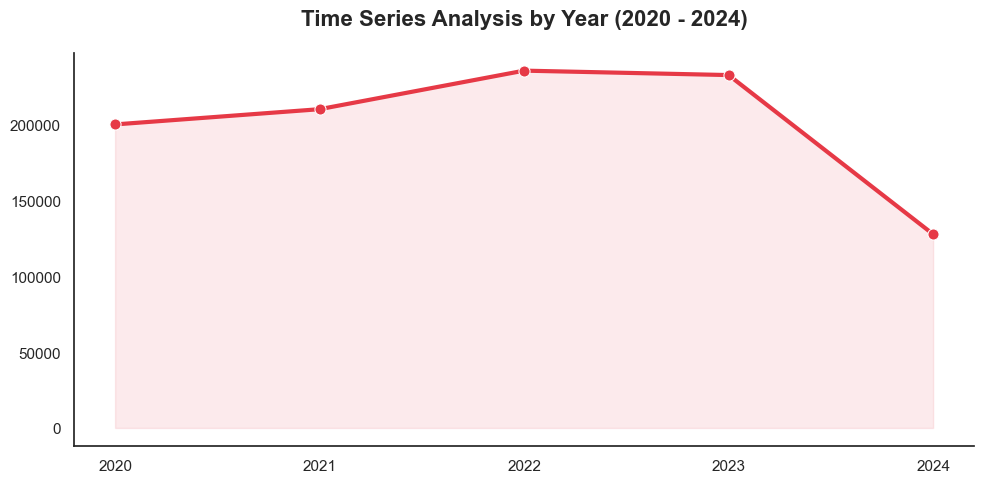

In [40]:
#reset_index(name='Total') turn result into a table of 2 Columns: 'DATE OCC' e 'Total'
crimes_per_year = df.groupby(df['DATE OCC'].dt.year).size().reset_index(name='Total')

# Set clean style (without grid)
sns.set_style("white") 
plt.figure(figsize=(10, 5))

# Create Line chart using 'data' parameter
sns.lineplot(
    data=crimes_per_year, 
    x='DATE OCC', 
    y='Total', 
    marker='o', 
    markersize=8, 
    color='#e63946', 
    linewidth=3
)

#Adiciona o preenchimento suave abaixo da linha
plt.fill_between(crimes_per_year['DATE OCC'], crimes_per_year['Total'], color='#e63946', alpha=0.1)

#Title for X e Y
plt.title('Time Series Analysis by Year (2020 - 2024)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('') 
plt.ylabel('') 

#Set X axis ticks to ensure proper year alignment
plt.xticks(ticks=crimes_per_year['DATE OCC'], labels=[str(int(ano)) for ano in crimes_per_year['DATE OCC']], fontsize=11)
plt.yticks(fontsize=11)

#Remove borders
sns.despine()

plt.tight_layout()
plt.show()

In [41]:
df['Month'] = df['DATE OCC'].dt.month

In [42]:
monthly_comparison = df.pivot_table(index='Month', columns = 'Year', values = 'DR_NO', aggfunc = 'count')

In [43]:
print(monthly_comparison)

Year    2020   2021   2022   2023   2024
Month                                   
1      18576  16636  18567  19970  18926
2      17284  15440  17750  18489  17394
3      16188  16354  19745  19214  16293
4      15706  16091  19837  18937  12946
5      17230  17020  20467  18908   9386
6      17060  17182  20273  18741   8126
7      17158  18690  20009  19935   8170
8      16902  18398  20144  20082   8324
9      15658  18386  19341  19321   8309
10     16510  19343  20335  20122   7817
11     15596  18374  18755  19074   7179
12     15979  17962  20036  19552   4697


In [44]:
df['Time_Clean'] = df['TIME OCC'].astype(str).str.zfill(4)

In [45]:
df['TIME_FORMATTED'] = pd.to_datetime(df['Time_Clean'], format='%H%M', errors='coerce').dt.time

In [46]:
def hour_extraction(value):
    if hasattr(value, 'hour'):
        return value.hour
    elif isinstance(value, str):
        return int(value[:2])
    else:
        return int(str(value).zfill(4)[:2])

In [47]:
df['HOUR'] = df['TIME_FORMATTED'].apply(hour_extraction)

In [48]:
print(df[['TIME_FORMATTED', 'HOUR']].head())

  TIME_FORMATTED  HOUR
0       08:45:00     8
1       18:45:00    18
2       12:40:00    12
3       13:10:00    13
4       18:30:00    18


In [49]:
frequent_hours = df['HOUR'].value_counts().sort_index().reset_index()

In [50]:
Total_Occurrences = df_crime 

In [51]:
frequent_hours.columns = ['Hour', 'Total_Occurrences']

In [52]:
print(frequent_hours)

    Hour  Total_Occurrences
0      0              40467
1      1              29760
2      2              25214
3      3              22190
4      4              18756
5      5              17288
6      6              23184
7      7              26264
8      8              37243
9      9              36519
10    10              43020
11    11              43663
12    12              67806
13    13              45572
14    14              49295
15    15              52811
16    16              52968
17    17              58809
18    18              59955
19    19              55596
20    20              56349
21    21              50788
22    22              49100
23    23              42277


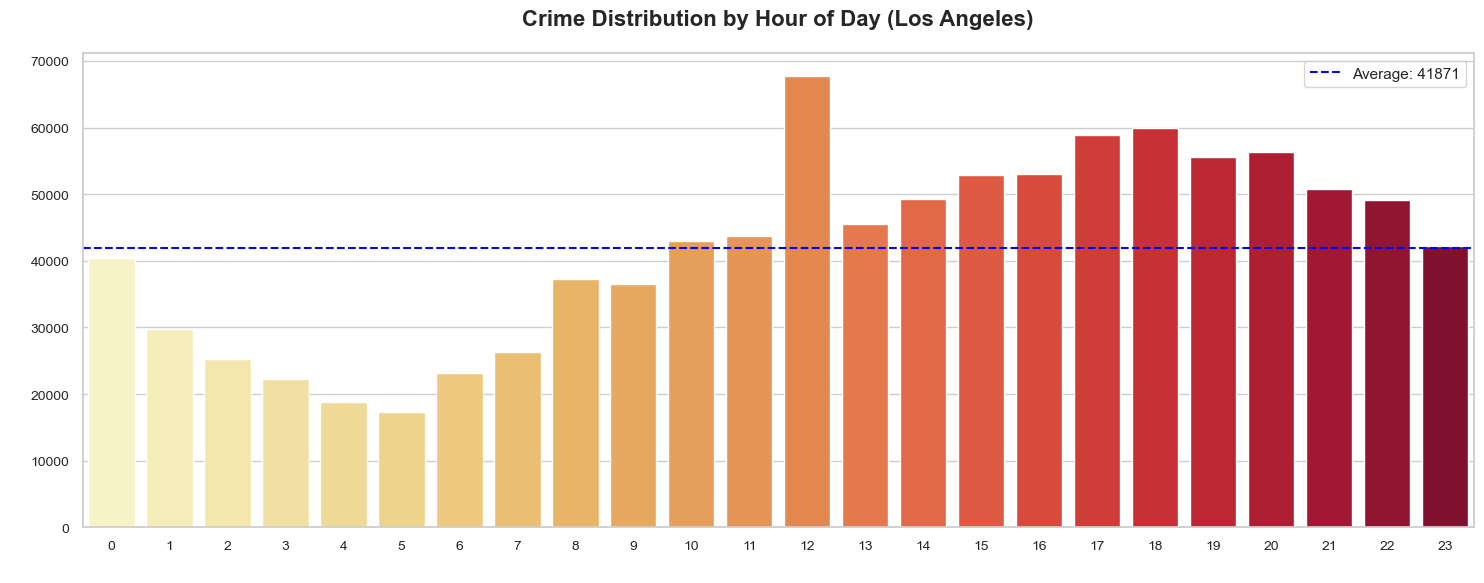

In [53]:
# Set the visual Style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# To create bars chart
plot = sns.barplot(
    data=frequent_hours, 
    x='Hour', 
    y='Total_Occurrences', 
    palette='YlOrRd'
)

# Customize the titles and axis
plt.title('Crime Distribution by Hour of Day (Los Angeles)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel(' ', fontsize=12)
plt.ylabel(' ', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 5. Add a line to show the average as reference
average_crimes = frequent_hours['Total_Occurrences'].mean()
plt.axhline(average_crimes, color='blue', linestyle='--', label=f'Average: {average_crimes:.0f}')
plt.legend()

# Show the chart
plt.tight_layout()
plt.show()

In [54]:
print(df['TIME_FORMATTED'].dtype)

object


In [55]:
type(df['TIME_FORMATTED'].iloc[0])

datetime.time

In [56]:
mapa_area = df[['AREA', 'AREA NAME']].drop_duplicates().set_index('AREA')['AREA NAME'].to_dict()

In [57]:
df['Area_crime'] = df_crime['Cod_Crime'].map(mapa_crime)

In [58]:
Crime_agg = df.groupby(['HOUR', 'Crm Cd Desc']).size().reset_index(name='Total')

In [59]:
top_crimes = Crime_agg[Crime_agg['HOUR'] == 17].sort_values(by='Total', ascending=False).copy()

In [60]:
top_crimes = top_crimes.reset_index(drop = True)

In [61]:
top_crimes.head(5)

,HOUR,Crm Cd Desc,Total
0,17,VEHICLE - STOLEN,7470
1,17,BATTERY - SIMPLE ASSAULT,4580
2,17,BURGLARY FROM VEHICLE,3968
3,17,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",3563
4,17,BURGLARY,3556


In [62]:
area_map = df[['AREA', 'AREA NAME']].drop_duplicates().sort_values(by='AREA').reset_index(drop=True)

In [63]:
crime_by_area = df.groupby(['AREA', 'AREA NAME', 'LOCATION']).size().reset_index(name='Total_Crimes')

In [64]:
top_areas = crime_by_area.sort_values(by = 'Total_Crimes', ascending = False)

In [65]:
top_areas.head(5)

,AREA,AREA NAME,LOCATION,Total_Crimes
1016,1,Central,800 N ALAMEDA ST,2598
950,1,Central,700 S FIGUEROA ST,1711
17154,7,Wilshire,100 THE GROVE DR,1688
20179,8,West LA,10200 SANTA MONICA BL,1657
20760,8,West LA,11800 SANTA MONICA BL,1526


In [66]:
mo_series = df['Mocodes'].dropna()

In [67]:
top_10_mocodes = mo_series.str.split().explode().value_counts().head(10)

In [68]:
print(top_10_mocodes)

Mocodes
1822    342151
0344    256854
0913    151097
0416    117837
0329    108375
1300     97383
2000     73728
0400     72708
1402     58609
2004     51803
Name: count, dtype: int64


In [69]:
#Mocodes are how the crime was made
dic_top_10_mocodes = {
    "1822": "Catalytic Converter Theft",
    "0344": "Elderly Victim (60+)",
    "0913": "Surveillance Camera Present (CCTV)",
    "0416": "Victim and Suspect Known to Each Other",
    "0329": "Forced Entry (Burglary)",
    "1300": "Verbal Threat",
    "2000": "Vandalism/Graffiti",
    "0400": "Victim is a Tourist",
    "1402": "Suspect Used Physical Force",
    "2004": "Vandalism of Public Property"
}

In [78]:
top_10_mocodes.index = top_10_mocodes.index.astype(str)

In [79]:
top_10_renamed = top_10_mocodes.rename(index=dic_top_10_mocodes)

In [80]:
print("Tipo do indice:", type(top_10_mocodes.index[0]))

Tipo do indice: <class 'str'>


In [81]:
print("Valores do indice:", top_10_mocodes.index.tolist())

Valores do indice: ['1822', '0344', '0913', '0416', '0329', '1300', '2000', '0400', '1402', '2004']


In [82]:
print("Chaves do dicionario:", list(dic_top_10_mocodes.keys()))

Chaves do dicionario: ['1822', '0344', '0913', '0416', '0329', '1300', '2000', '0400', '1402', '2004']


In [83]:
print(top_10_renamed)

Mocodes
Catalytic Converter Theft                 342151
Elderly Victim (60+)                      256854
Surveillance Camera Present (CCTV)        151097
Victim and Suspect Known to Each Other    117837
Forced Entry (Burglary)                   108375
Verbal Threat                              97383
Vandalism/Graffiti                         73728
Victim is a Tourist                        72708
Suspect Used Physical Force                58609
Vandalism of Public Property               51803
Name: count, dtype: int64


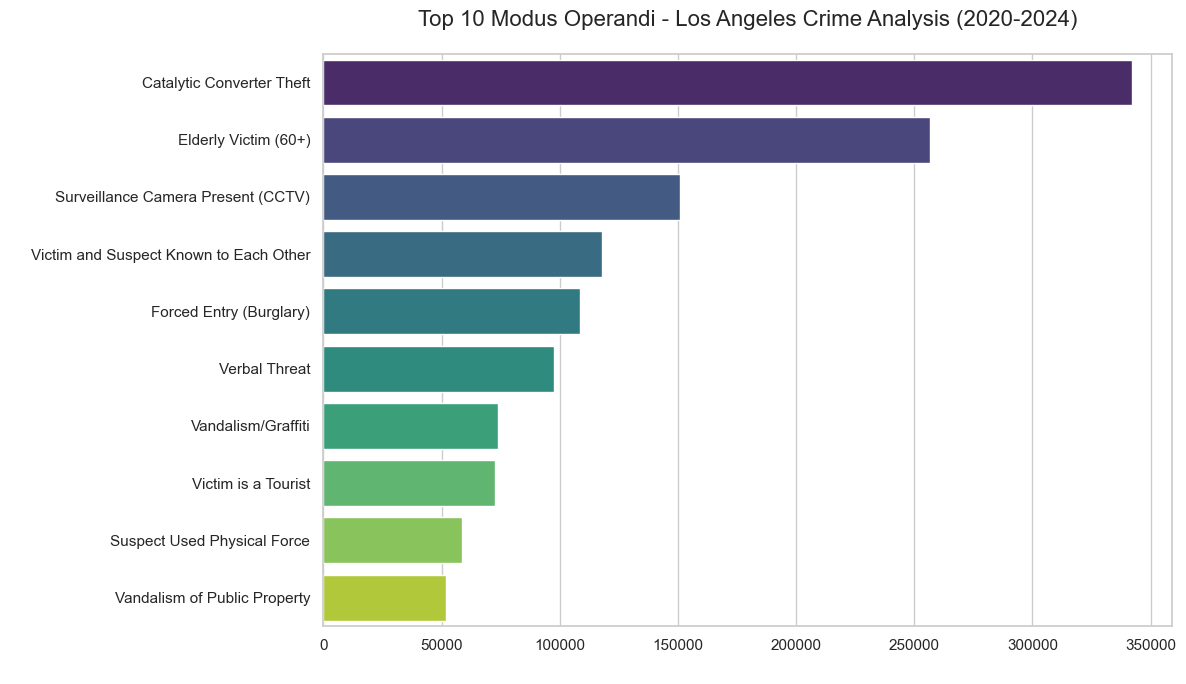

In [86]:
df_plot = top_10_mocodes.reset_index()
df_plot.columns = ['Code', 'Count']

# Apply the mapping (ensuring string type to avoid NaN)
df_plot['Description'] = df_plot['Code'].astype(str).map(dic_top_10_mocodes)

#Visualization setup
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Create the horizontal bar chart
# Using 'viridis' palette 
plot = sns.barplot(
    data=df_plot, 
    x='Count', 
    y='Description', 
    palette='viridis'
)

# English Labels and Titles
plt.title('Top 10 Modus Operandi - Los Angeles Crime Analysis (2020-2024)', fontsize=16, pad=20)
plt.xlabel(' ', fontsize=12)
plt.ylabel(' ', fontsize=12)

# Adjust layout to prevent text clipping
plt.tight_layout()
plt.show()

In [87]:
df_vict = df[(df['Vict Age'] > 0) & (df['Vict Age'] < 100)].copy()

In [88]:
descent_sex = {
    'A': 'Other Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian', 'F': 'Filipino',
    'G': 'Guamanian', 'H': 'Hispanic/Latin/Mexican', 'I': 'American Indian/Alaskan Native',
    'J': 'Japanese', 'K': 'Korean', 'L': 'Laotian', 'O': 'Other', 'P': 'Pacific Islander',
    'S': 'Samoan', 'U': 'Hawaiian', 'V': 'Vietnamese', 'W': 'White', 'Z': 'Asian Indian'
}

In [89]:
df_vict['Vict Descent Desc'] = df_vict['Vict Descent'].map(descent_sex)

In [90]:
sex_mapping = {'F': 'Female', 'M': 'Male', 'X': 'Unknown'}
df_vict['Vict Sex Desc'] = df_vict['Vict Sex'].map(sex_mapping)

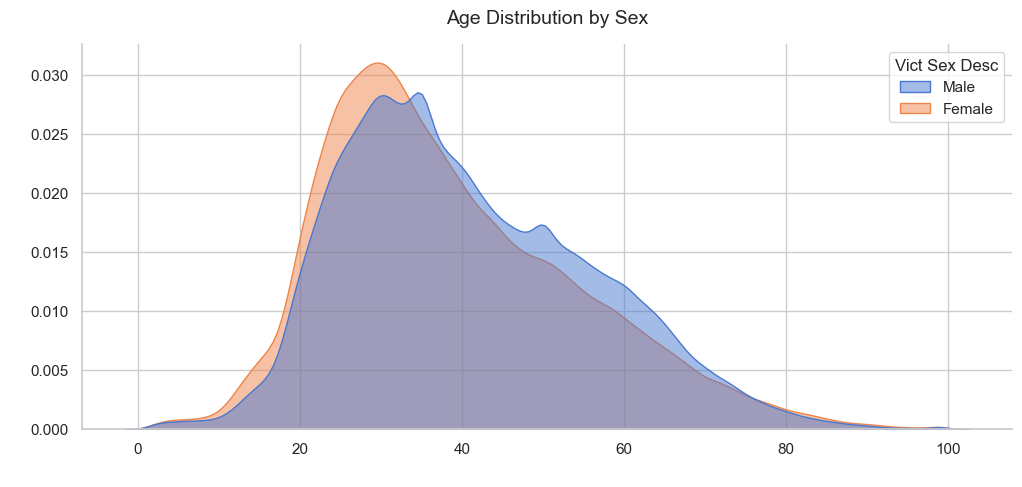

In [91]:
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_vict[df_vict['Vict Sex Desc'].isin(['Female', 'Male'])], 
            x='Vict Age', hue='Vict Sex Desc', fill=True, common_norm=False, palette='muted', alpha=0.5)
plt.title('Age Distribution by Sex', fontsize=14, pad=15)
plt.xlabel(' ', fontsize=12)
plt.ylabel(' ', fontsize=12)
sns.despine()
plt.show()

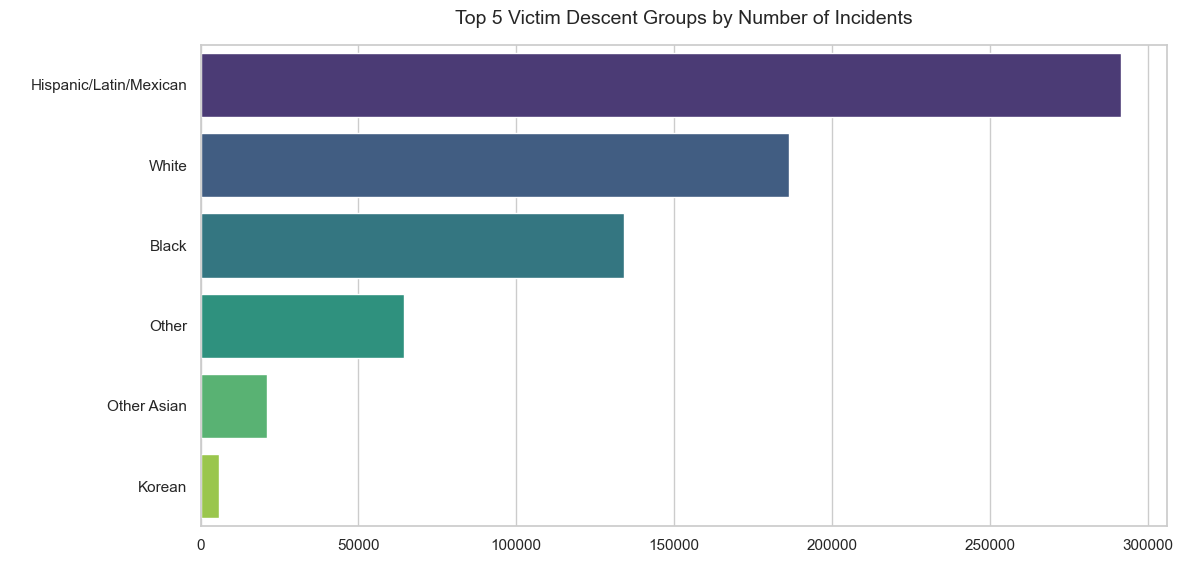

In [92]:
plt.figure(figsize=(12, 6))
top_descents = df_vict['Vict Descent Desc'].value_counts().head(6)
sns.barplot(x=top_descents.values, y=top_descents.index, palette='viridis')
plt.title('Top 5 Victim Descent Groups by Number of Incidents', fontsize=14, pad=15)
plt.xlabel(' ', fontsize=12)
plt.ylabel(' ', fontsize=12)
plt.tight_layout()
plt.show()

In [95]:
top_crimes = df_vict['Crm Cd Desc'].value_counts().head(5).index
profile_table = df_vict[df_vict['Crm Cd Desc'].isin(top_crimes)].pivot_table(
    values='Vict Age', 
    index='Crm Cd Desc', 
    columns='Vict Sex Desc', 
    aggfunc='count'
)
display(profile_table.round(1))


Vict Sex Desc,Female,Male,Unknown
Crm Cd Desc,,,
"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",14059,36954,472
BATTERY - SIMPLE ASSAULT,34788,38812,269
BURGLARY FROM VEHICLE,26456,34821,259
THEFT OF IDENTITY,35712,25440,174
THEFT PLAIN - PETTY ($950 & UNDER),23161,23205,550


In [96]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'])

In [97]:
df['Days_to_registry'] = (df['Date Rptd'] - df['DATE OCC']).dt.days

In [98]:
df_tempo = df[df['Days_to_registry'] >= 0].copy()

In [99]:
def categorize_time(dias):
    if dias == 0: return 'Same day'
    elif dias == 1: return 'after 1 day'
    elif dias <= 7: return '2 to 7 days (1 week)'
    elif dias <= 30: return '8 a 30 days (1 month)'
    else: return 'More than 1 month'

In [100]:
df_tempo['Categoria_Delay'] = df_tempo['Days_to_registry'].apply(categorize_time)

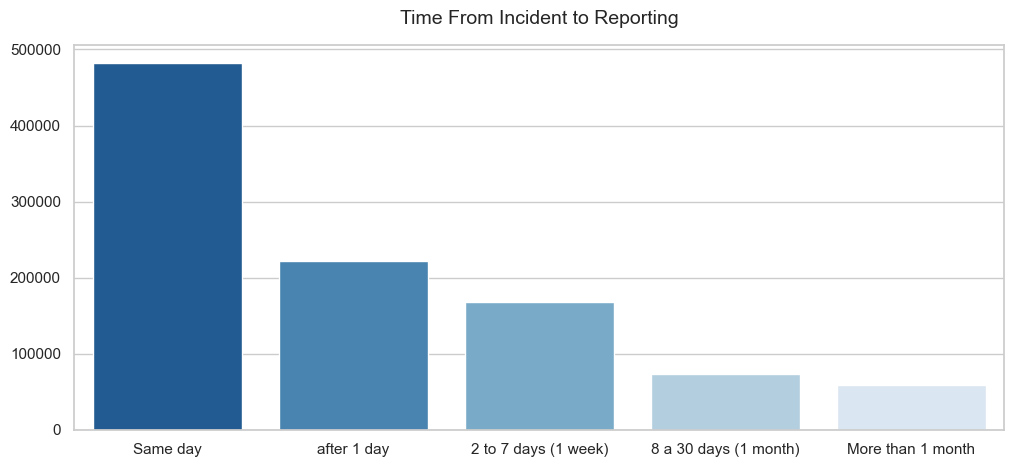

In [101]:
plt.figure(figsize=(12, 5))
category_order = ['Same day', 'after 1 day', '2 to 7 days (1 week)', '8 a 30 days (1 month)', 'More than 1 month']
sns.countplot(data=df_tempo, x='Categoria_Delay', order=category_order, palette='Blues_r')
plt.title('Time From Incident to Reporting', fontsize=14, pad=15)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.show()

In [102]:
delayed = df_tempo.groupby('Crm Cd Desc')['Days_to_registry'].agg(['mean', 'count'])

In [103]:
delayed = delayed[delayed['count'] > 100].sort_values(by='mean', ascending=False).head(10)
display(delayed.rename(columns={'mean': 'Average of Days', 'count': 'Total OF Ocurrences'}))

,Average of Days,Total OF Ocurrences
Crm Cd Desc,,
CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER),157.331828,1772
SEX OFFENDER REGISTRANT OUT OF COMPLIANCE,124.903727,966
"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ",120.861111,1080
ORAL COPULATION,81.486933,727
SEXUAL PENETRATION W/FOREIGN OBJECT,80.729750,1321
THEFT OF IDENTITY,68.506076,62536
"RAPE, FORCIBLE",66.237753,3756
CHILD ANNOYING (17YRS & UNDER),65.585646,1045
SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH,65.186441,531
